<a href="https://colab.research.google.com/github/leabourhis2/maplibre/blob/main/cha%C3%AEne_de_traitement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⚕️Repérer les zones blanches pharmaceutiques en Bretagne : Que valent vraiment les isochrones OSMR et OSMRX ?

#🧰 Configuration environnement de travail

In [ ]:
# @title
#Initialisation de l'environnement avec geopandas
!apt update
!apt install gdal-bin python-gdal python3-gdal
# Install rtree - Geopandas requirment
!apt install python3-rtree
# Install Geopandas
!pip install geopandas
# Install Fiona
!pip install Fiona
# Instal contextily (fonds de carte)
!pip install contextily
# Install mapclassify (cartographie thématique)
!pip install mapclassify
# Depuis sa version 0.8, Geopandas peut fonctionner de manière expérimental avec Pygeos ce qui accèlère certaines opérations
!pip install pygeos
# Pour la cartographie interactive
!pip install folium
# Install scalebar
!pip install matplotlib_scalebar

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:5 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:6 https://cli.github.com/packages stable InRelease [3,917 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [7,143 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,226 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,889 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1

In [ ]:
#Importation des librairies nécessaires
import pandas as pd #Gestion de données
import matplotlib.pyplot as plt #Visualisation de données
import geopandas as gpd #Gestion données spatiales
import contextily as ctx #Fonds de carte
import fiona as np #lecture et écriture de données spatiales
import numpy as np #Manipulation de tableaux
import shapely #Manipulation de géométrie
import folium #Cartographie interactive
import mapclassify #Cartographie thématique
from matplotlib_scalebar.scalebar import ScaleBar #Echelle cartographique


# 📥 Importer et préparer les couches pharmacies et communes

## Récupération et préparation des données

In [ ]:
#Téléchargement des datas depuis les sites opendata d
!wget -O Pharmacie.geojson https://public.opendatasoft.com/api/explore/v2.1/catalog/datasets/healthref-france-finess/exports/geojson?lang=fr&refine=reg_name%3A%22Bretagne%22&refine=libcategetab%3A%22Pharmacie%20d%27Officine%22&timezone=Europe%2FBerlin
!wget -O Communes.geojson https://public.opendatasoft.com/api/explore/v2.1/catalog/datasets/georef-france-commune/exports/geojson/?lang=fr&refine=reg_name%3ABretagne&timezone=Europe%2FParis

--2026-04-10 08:50:38--  https://public.opendatasoft.com/api/explore/v2.1/catalog/datasets/healthref-france-finess/exports/geojson?lang=fr
Resolving public.opendatasoft.com (public.opendatasoft.com)... 52.211.64.165, 18.200.140.238
Connecting to public.opendatasoft.com (public.opendatasoft.com)|52.211.64.165|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/json]
Saving to: ‘Pharmacie.geojson’

Pharmacie.geojson       [              <=>   ] 119.87M  4.31MB/s    in 25s     

2026-04-10 08:51:03 (4.88 MB/s) - ‘Pharmacie.geojson’ saved [125692880]

--2026-04-10 08:51:03--  https://public.opendatasoft.com/api/explore/v2.1/catalog/datasets/georef-france-commune/exports/geojson/?lang=fr
Resolving public.opendatasoft.com (public.opendatasoft.com)... 52.211.64.165, 18.200.140.238
Connecting to public.opendatasoft.com (public.opendatasoft.com)|52.211.64.165|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [app

/usr/local/lib/python3.12/dist-packages/geopandas/io/file.py:576: UserWarning: Error parsing datetimes, original strings are returned: Out of bounds nanosecond timestamp: 0426-03-01, at position 5150. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.
  return pyogrio.read_dataframe(path_or_bytes, bbox=bbox, **kwargs)
/usr/local/lib/python3.12/dist-packages/geopandas/io/file.py:576: UserWarning: Error parsing datetimes, original strings are returned: Out of bounds nanosecond timestamp: 0459-01-14, at position 4028. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly t

,nofinesset,nofinessej,rs,rslongue,complrs,compldistrib,numvoie,typvoie,voie,compvoie,...,sourcecoordet,datemaj_geo,com_name,reg_code,reg_name,epci_code,epci_name,address,coord,geometry
0,130783103,130037880,PETITES SOEURS DES PAUVRES MA MAISON,PETITES SOEURS DES PAUVRES MA MAISON EHPAD,EHPAD,None,29.0,R,JEANNE JUGAN,None,...,"2,ATLASANTE,100,BDADRESSE_v2.2_03-2024,LAMBERT...",2024-09-03,Marseille,93,Provence-Alpes-Côte d'Azur,200054807,Métropole d'Aix-Marseille-Provence,29 R JEANNE JUGAN,None,POINT (5.39978 43.31046)
1,130055502,130014228,HOPITAL ST JOSEPH,None,SERV AUTONOME PREV SANTE TRAVAIL,None,26.0,BD,DE LOUVAIN,None,...,"1,ATLASANTE,100,BDADRESSE_v2.2_03-2024,LAMBERT...",2024-09-03,Marseille,93,Provence-Alpes-Côte d'Azur,200054807,Métropole d'Aix-Marseille-Provence,26 BD DE LOUVAIN,None,POINT (5.39256 43.27626)
2,130782451,130001118,LE MEDITERRANEE CLINIQUE CASTELLAS,LE MEDITERRANEE CLINIQUE DE SOINS DE SUITE DU ...,None,None,NaN,BD,KENNEDY QUARTIER LE PIJORET,None,...,"2,ATLASANTE,84,BDADRESSE_v2.2_03-2024,LAMBERT_...",2024-09-03,La Roque-d'Anthéron,93,Provence-Alpes-Côte d'Azur,200054807,Métropole d'Aix-Marseille-Provence,BD KENNEDY QUARTIER LE PIJORET,None,POINT (5.30709 43.71557)
3,130785215,130805062,FOYER D'HEBGT CAT LA FARIGOULE,FOYER HEBERGEMENT DU CENTRE D'AIDE PAR LE TRAV...,None,None,2.0,R,DU PIGEONNIER,None,...,"1,ATLASANTE,100,BDADRESSE_v2.2_03-2024,LAMBERT...",2024-09-03,La Roque-d'Anthéron,93,Provence-Alpes-Côte d'Azur,200054807,Métropole d'Aix-Marseille-Provence,2 R DU PIGEONNIER,None,POINT (5.30836 43.71249)
4,130784416,130001746,IME LES MARRONNIERS,INSTITUT MEDICO-EDUCATIF LES MARRONNIERS,None,None,31.0,BD,DE SAINT LOUP,None,...,"1,ATLASANTE,100,BDADRESSE_v2.2_03-2024,LAMBERT...",2024-09-03,Marseille,93,Provence-Alpes-Côte d'Azur,200054807,Métropole d'Aix-Marseille-Provence,31 BD DE SAINT LOUP,None,POINT (5.4297 43.28261)


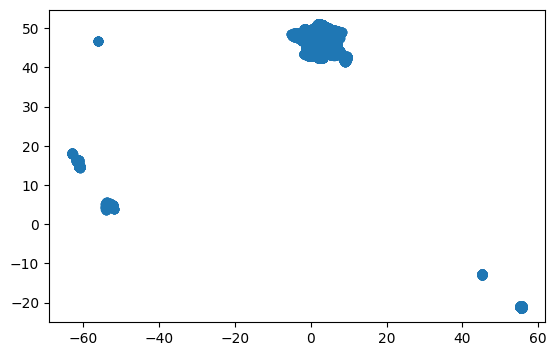

In [ ]:
#Importer la couche des Pharmacies

Pharmacie= gpd.read_file("Pharmacie.geojson", encoding='utf-8')
Pharmacie.plot()
Pharmacie.head(5)

,geo_point_2d,year,reg_code,reg_name,dep_code,dep_name,arrdep_code,arrdep_name,ze2020_code,ze2020_name,...,com_cateaav2020_code,com_cateaav2020_name,com_uu2020_code,com_uu2020_status,com_aav2020_code,com_cv_code,com_in_ctu,com_siren_code,com_is_mountain_area,geometry
0,"{'lon': 2.2867022671589505, 'lat': 46.02015835...",2025,[75],[Nouvelle-Aquitaine],[23],[Creuse],[231],[Aubusson],[7511],[Guéret],...,20,Commune de la couronne,23000,hors unité urbaine,419,2302,Non,212304802,Non,"POLYGON ((2.27793 45.99085, 2.27791 45.99156, ..."
1,"{'lon': 2.1265431779148565, 'lat': 45.74427413...",2025,[75],[Nouvelle-Aquitaine],[23],[Creuse],[231],[Aubusson],[7511],[Guéret],...,30,Commune hors attraction des villes,23000,hors unité urbaine,000,2309,Non,212308001,Oui,"POLYGON ((2.15657 45.72163, 2.15798 45.72354, ..."
2,"{'lon': 2.7528896723892973, 'lat': 44.98045657...",2025,[84],[Auvergne-Rhône-Alpes],[15],[Cantal],[153],[Saint-Flour],[8403],[Aurillac],...,30,Commune hors attraction des villes,15000,hors unité urbaine,000,1512,Non,211501127,Oui,"POLYGON ((2.7384 44.94144, 2.73916 44.94197, 2..."
3,"{'lon': 2.275125311360464, 'lat': 50.912654832...",2025,[32],[Hauts-de-France],[59],[Nord],[594],[Dunkerque],[3213],[Dunkerque],...,20,Commune de la couronne,59000,hors unité urbaine,048,5920,Non,215903584,Non,"POLYGON ((2.3139 50.9027, 2.31232 50.90355, 2...."
4,"{'lon': 2.657332186761346, 'lat': 50.717955413...",2025,[32],[Hauts-de-France],[59],[Nord],[594],[Dunkerque],[3216],[Lille],...,20,Commune de la couronne,59000,hors unité urbaine,004,5908,Non,215903998,Non,"POLYGON ((2.67674 50.69892, 2.67652 50.6994, 2..."


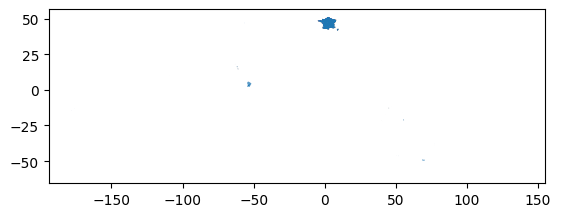

In [ ]:
#Importer la couche des Communes

Communes= gpd.read_file("Communes.geojson", encoding='utf-8')
Communes.plot()
Communes.head(5)

In [ ]:
# Ne garder que les colonne importantes pour les Pharmacies

PharmacieOK = Pharmacie[["dep_code", "dep_name", "com_name","rs","com_code","geometry"]]
PharmacieOK.head()

,dep_code,dep_name,com_name,rs,com_code,geometry
0,13,BOUCHES DU RHONE,Marseille,PETITES SOEURS DES PAUVRES MA MAISON,13204,POINT (5.39978 43.31046)
1,13,BOUCHES DU RHONE,Marseille,HOPITAL ST JOSEPH,13208,POINT (5.39256 43.27626)
2,13,BOUCHES DU RHONE,La Roque-d'Anthéron,LE MEDITERRANEE CLINIQUE CASTELLAS,13084,POINT (5.30709 43.71557)
3,13,BOUCHES DU RHONE,La Roque-d'Anthéron,FOYER D'HEBGT CAT LA FARIGOULE,13084,POINT (5.30836 43.71249)
4,13,BOUCHES DU RHONE,Marseille,IME LES MARRONNIERS,13210,POINT (5.4297 43.28261)


In [ ]:
# Ne garder que les colonne importantes pour les Communes

CommunesOK = Communes[["dep_code", "dep_name", "com_name","com_uu2020_status","com_code","geometry"]]
CommunesOK.head()

,dep_code,dep_name,com_name,com_uu2020_status,com_code,geometry
0,[23],[Creuse],[Champagnat],hors unité urbaine,[23048],"POLYGON ((2.27793 45.99085, 2.27791 45.99156, ..."
1,[23],[Creuse],[Féniers],hors unité urbaine,[23080],"POLYGON ((2.15657 45.72163, 2.15798 45.72354, ..."
2,[15],[Cantal],[Malbo],hors unité urbaine,[15112],"POLYGON ((2.7384 44.94144, 2.73916 44.94197, 2..."
3,[59],[Nord],[Looberghe],hors unité urbaine,[59358],"POLYGON ((2.3139 50.9027, 2.31232 50.90355, 2...."
4,[59],[Nord],[Merris],hors unité urbaine,[59399],"POLYGON ((2.67674 50.69892, 2.67652 50.6994, 2..."


In [ ]:
#Supprimer les [] dans la colonne com_code pour les communes

CommunesOK["com_code"] = CommunesOK["com_code"].apply(lambda x: x[0])
CommunesOK.head()

/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,dep_code,dep_name,com_name,com_uu2020_status,com_code,geometry
0,[23],[Creuse],[Champagnat],hors unité urbaine,23048,"POLYGON ((2.27793 45.99085, 2.27791 45.99156, ..."
1,[23],[Creuse],[Féniers],hors unité urbaine,23080,"POLYGON ((2.15657 45.72163, 2.15798 45.72354, ..."
2,[15],[Cantal],[Malbo],hors unité urbaine,15112,"POLYGON ((2.7384 44.94144, 2.73916 44.94197, 2..."
3,[59],[Nord],[Looberghe],hors unité urbaine,59358,"POLYGON ((2.3139 50.9027, 2.31232 50.90355, 2...."
4,[59],[Nord],[Merris],hors unité urbaine,59399,"POLYGON ((2.67674 50.69892, 2.67652 50.6994, 2..."


,dep_code,dep_name,com_name,rs,com_code,geometry
1338,56,MORBIHAN,Ploërmel,CENTRE HOSPITALIER DE PLOERMEL,56165,POINT (-2.39165 47.93484)
1339,56,MORBIHAN,Ploërmel,IME LES BRUYERES,56165,POINT (-2.39039 47.92252)
1340,56,MORBIHAN,Gourin,RESIDENCE MENEZ DU,56066,POINT (-3.60237 48.13951)
1341,56,MORBIHAN,Sarzeau,EHPAD PIERRE DE FRANCHEVILLE,56240,POINT (-2.76352 47.52435)
1342,56,MORBIHAN,Saint-Jean-Brévelay,EHPAD VILLAGE DU PORHOET,56222,POINT (-2.71495 47.84595)


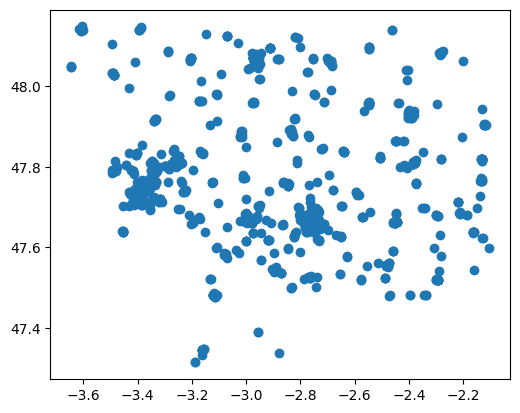

In [ ]:
#Selectionner le territoire d'étude
Pharmacie35 = PharmacieOK[(PharmacieOK["dep_code"] == "56")]
Pharmacie35.plot()
Pharmacie35.head(5)

,dep_code,dep_name,com_name,com_uu2020_status,com_code,geometry
172,[56],[Morbihan],[Baud],unité urbaine,56010,"POLYGON ((-3.04257 47.82792, -3.04108 47.82757..."
265,[56],[Morbihan],[Réminiac],hors unité urbaine,56191,"POLYGON ((-2.28178 47.84677, -2.27979 47.84699..."
286,[56],[Morbihan],[Ambon],hors unité urbaine,56002,"POLYGON ((-2.58292 47.53743, -2.58228 47.53713..."
332,[56],[Morbihan],[Noyal-Pontivy],unité urbaine,56151,"POLYGON ((-2.92309 48.10619, -2.92513 48.10593..."
412,[56],[Morbihan],[Meslan],hors unité urbaine,56131,"POLYGON ((-3.40358 47.96697, -3.40349 47.96766..."


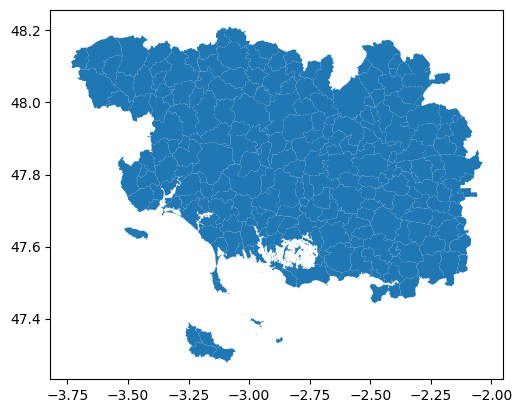

In [ ]:
#Selectionner le territoire d'étude
Communes35 = CommunesOK[(CommunesOK["dep_code"] == "56")]
Communes35.plot()
Communes35.head(5)

##Récupérer le fichier de population

In [ ]:
#Téléchargement du csv de la population des communes
!wget -O population.zip https://www.insee.fr/fr/statistiques/fichier/8680726/ensemble.zip

--2026-04-10 08:57:54--  https://www.insee.fr/fr/statistiques/fichier/8680726/ensemble.zip
Resolving www.insee.fr (www.insee.fr)... 194.254.37.163
Connecting to www.insee.fr (www.insee.fr)|194.254.37.163|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘population.zip’

population.zip          [  <=>               ]   1008K  3.67MB/s    in 0.3s    

2026-04-10 08:57:55 (3.67 MB/s) - ‘population.zip’ saved [1032385]



In [ ]:
#Importer CSV to dataframe
!unzip -o population.zip
population = pd.read_csv('donnees_communes.csv', sep=';')
population.head(3)

Archive:  population.zip
  inflating: donnees_arrondissements.csv  
  inflating: donnees_cantons.csv     
  inflating: donnees_collectivites.csv  
  inflating: donnees_communes.csv    
  inflating: donnees_communes_deleguees.csv  
  inflating: donnees_departements.csv  
  inflating: donnees_fractions_cantonales.csv  
  inflating: donnees_regions.csv     
  inflating: metadonnees.csv         


,REG,Région,DEP,CODARR,CODCAN,CODCOM,COM,Commune,PMUN,PCAP,PTOT
0,84,Auvergne-Rhône-Alpes,01,2,8.0,1,01001,L'Abergement-Clémenciat,860,16,876
1,84,Auvergne-Rhône-Alpes,01,1,1.0,2,01002,L'Abergement-de-Varey,270,6,276
2,84,Auvergne-Rhône-Alpes,01,1,1.0,4,01004,Ambérieu-en-Bugey,15934,405,16339


In [ ]:
#Selectionner le territoire d'étude
population35 = population[(population["DEP"] == "56")]
population35.head(5)

,REG,Région,DEP,CODARR,CODCAN,CODCOM,COM,Commune,PMUN,PCAP,PTOT
20479,53,Bretagne,56,3,4.0,1,56001,Allaire,3955,85,4040
20480,53,Bretagne,56,3,11.0,2,56002,Ambon,2101,55,2156
20481,53,Bretagne,56,3,20.0,3,56003,Arradon,5835,159,5994
20482,53,Bretagne,56,3,11.0,4,56004,Arzal,1846,27,1873
20483,53,Bretagne,56,3,18.0,5,56005,Arzon,2271,38,2309


Préparer le fichier

In [ ]:
# Ne garder que les colonne importantes pour la population

population35 = population35[["Région", "DEP", "COM","Commune","PTOT"]]
population35.head()

,Région,DEP,COM,Commune,PTOT
20479,Bretagne,56,56001,Allaire,4040
20480,Bretagne,56,56002,Ambon,2156
20481,Bretagne,56,56003,Arradon,5994
20482,Bretagne,56,56004,Arzal,1873
20483,Bretagne,56,56005,Arzon,2309


In [ ]:
#Renommer les colonnes

population35 = population35.rename(columns={ 'COM':'insee_code', 'PTOT': 'Population'})
population35.head()

,Région,DEP,insee_code,Commune,Population
20479,Bretagne,56,56001,Allaire,4040
20480,Bretagne,56,56002,Ambon,2156
20481,Bretagne,56,56003,Arradon,5994
20482,Bretagne,56,56004,Arzal,1873
20483,Bretagne,56,56005,Arzon,2309


In [ ]:
#Changer le type d'une colonne
population35['insee_code'] = population35['insee_code'].astype(str)

Jointure attributaire

In [ ]:
Communes35.head(3)

,dep_code,dep_name,com_name,com_uu2020_status,com_code,geometry
172,[56],[Morbihan],[Baud],unité urbaine,56010,"POLYGON ((-3.04257 47.82792, -3.04108 47.82757..."
265,[56],[Morbihan],[Réminiac],hors unité urbaine,56191,"POLYGON ((-2.28178 47.84677, -2.27979 47.84699..."
286,[56],[Morbihan],[Ambon],hors unité urbaine,56002,"POLYGON ((-2.58292 47.53743, -2.58228 47.53713..."


In [ ]:
# Faire la jointure attributaire

Communes35POP = Communes35.merge(population35, left_on='com_code', right_on='insee_code')
Communes35POP.head()

,dep_code,dep_name,com_name,com_uu2020_status,com_code,geometry,Région,DEP,insee_code,Commune,Population
0,[56],[Morbihan],[Baud],unité urbaine,56010,"POLYGON ((-3.04257 47.82792, -3.04108 47.82757...",Bretagne,56,56010,Baud,6519
1,[56],[Morbihan],[Réminiac],hors unité urbaine,56191,"POLYGON ((-2.28178 47.84677, -2.27979 47.84699...",Bretagne,56,56191,Réminiac,447
2,[56],[Morbihan],[Ambon],hors unité urbaine,56002,"POLYGON ((-2.58292 47.53743, -2.58228 47.53713...",Bretagne,56,56002,Ambon,2156
3,[56],[Morbihan],[Noyal-Pontivy],unité urbaine,56151,"POLYGON ((-2.92309 48.10619, -2.92513 48.10593...",Bretagne,56,56151,Noyal-Pontivy,3704
4,[56],[Morbihan],[Meslan],hors unité urbaine,56131,"POLYGON ((-3.40358 47.96697, -3.40349 47.96766...",Bretagne,56,56131,Meslan,1508


In [ ]:
# Vérifier la popuation de l'Ille-et-Vilaine

sum(Communes35POP["Population"])

804597

#🧮Calcul des indicateurs

## ⚕️Compter le nombre de pharmacie par commune

In [ ]:
# Vérifier les CRS

Communes35POP.crs
Pharmacie35.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [ ]:
# On associe chaque pharmacie à sa commune (jointure spatiale)
pharma_communes = gpd.sjoin(
    Pharmacie35,
    Communes35POP,
    how="left",
    predicate="within"
)

pharma_communes.head()

,dep_code_left,dep_name_left,com_name_left,rs,com_code_left,geometry,index_right,dep_code_right,dep_name_right,com_name_right,com_uu2020_status,com_code_right,Région,DEP,insee_code,Commune,Population
1338,56,MORBIHAN,Ploërmel,CENTRE HOSPITALIER DE PLOERMEL,56165,POINT (-2.39165 47.93484),221,[56],[Morbihan],[Ploërmel],unité urbaine,56165,Bretagne,56,56165,Ploërmel,10688
1339,56,MORBIHAN,Ploërmel,IME LES BRUYERES,56165,POINT (-2.39039 47.92252),221,[56],[Morbihan],[Ploërmel],unité urbaine,56165,Bretagne,56,56165,Ploërmel,10688
1340,56,MORBIHAN,Gourin,RESIDENCE MENEZ DU,56066,POINT (-3.60237 48.13951),178,[56],[Morbihan],[Gourin],unité urbaine,56066,Bretagne,56,56066,Gourin,4113
1341,56,MORBIHAN,Sarzeau,EHPAD PIERRE DE FRANCHEVILLE,56240,POINT (-2.76352 47.52435),96,[56],[Morbihan],[Sarzeau],unité urbaine,56240,Bretagne,56,56240,Sarzeau,9377
1342,56,MORBIHAN,Saint-Jean-Brévelay,EHPAD VILLAGE DU PORHOET,56222,POINT (-2.71495 47.84595),175,[56],[Morbihan],[Saint-Jean-Brévelay],hors unité urbaine,56222,Bretagne,56,56222,Saint-Jean-Brévelay,3004


In [ ]:
# Compter les pharmacies par commune

nb_pharma = (
    pharma_communes
    .groupby("insee_code")
    .size()
    .reset_index(name="nb_pharmacies")
)

nb_pharma.head(3)

,insee_code,nb_pharmacies
0,56001,7
1,56002,1
2,56003,6


In [ ]:
Communes35POP = Communes35POP.merge(
    nb_pharma,
    on="insee_code",
    how="left"
)
Communes35POP["nb_pharmacies"] = Communes35POP["nb_pharmacies"].fillna(0)
Communes35POP.head(3)

,dep_code,dep_name,com_name,com_uu2020_status,com_code,geometry,Région,DEP,insee_code,Commune,Population,nb_pharmacies
0,[56],[Morbihan],[Baud],unité urbaine,56010,"POLYGON ((-3.04257 47.82792, -3.04108 47.82757...",Bretagne,56,56010,Baud,6519,9.0
1,[56],[Morbihan],[Réminiac],hors unité urbaine,56191,"POLYGON ((-2.28178 47.84677, -2.27979 47.84699...",Bretagne,56,56191,Réminiac,447,0.0
2,[56],[Morbihan],[Ambon],hors unité urbaine,56002,"POLYGON ((-2.58292 47.53743, -2.58228 47.53713...",Bretagne,56,56002,Ambon,2156,1.0


Text(0.5, 0, 'nb_pharmacies')

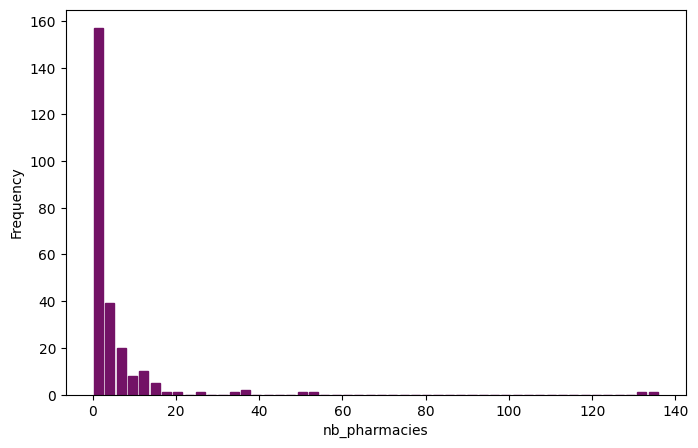

In [ ]:
# Histogramme de distribution du nombre de pharmacie par commune
ax = Communes35POP.plot.hist(y='nb_pharmacies', figsize=(8, 5), bins=50, rwidth=0.8, edgecolor='#731266', color='#731266',legend=False)
ax.set_xlabel("nb_pharmacies")

/tmp/ipykernel_5283/1485203441.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  CommunesOK_centro.geometry = CommunesOK_centro['geometry'].centroid


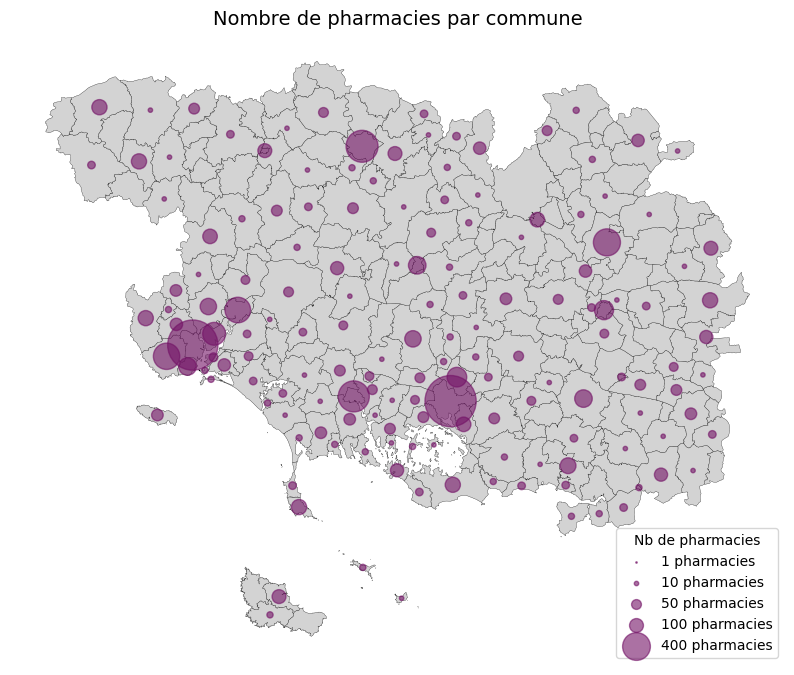

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Fond des communes
Communes35POP.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.2)

# Centroides avec cercles proportionnels
CommunesOK_centro = Communes35POP.copy()
CommunesOK_centro.geometry = CommunesOK_centro['geometry'].centroid

CommunesOK_centro.plot(
    ax=ax,
    markersize=CommunesOK_centro["nb_pharmacies"] * 10,
    color="#731266",
    alpha=0.6,
    legend=True
)
valeurs = [1, 10, 50, 100, 400]
for v in valeurs:
    ax.scatter([], [], s=v * 1, color="#731266", alpha=0.6, label=f"{v} pharmacies")

ax.legend(title="Nb de pharmacies", loc="lower right")
ax.set_title("Nombre de pharmacies par commune", fontsize=14)
ax.axis("off")
plt.show()


##⚕️📈Combien de pharmacie pour 1000 habitants ?

In [ ]:
Communes35POP.head()

,dep_code,dep_name,com_name,com_uu2020_status,com_code,geometry,Région,DEP,insee_code,Commune,Population,nb_pharmacies
0,[56],[Morbihan],[Baud],unité urbaine,56010,"POLYGON ((-3.04257 47.82792, -3.04108 47.82757...",Bretagne,56,56010,Baud,6519,9.0
1,[56],[Morbihan],[Réminiac],hors unité urbaine,56191,"POLYGON ((-2.28178 47.84677, -2.27979 47.84699...",Bretagne,56,56191,Réminiac,447,0.0
2,[56],[Morbihan],[Ambon],hors unité urbaine,56002,"POLYGON ((-2.58292 47.53743, -2.58228 47.53713...",Bretagne,56,56002,Ambon,2156,1.0
3,[56],[Morbihan],[Noyal-Pontivy],unité urbaine,56151,"POLYGON ((-2.92309 48.10619, -2.92513 48.10593...",Bretagne,56,56151,Noyal-Pontivy,3704,10.0
4,[56],[Morbihan],[Meslan],hors unité urbaine,56131,"POLYGON ((-3.40358 47.96697, -3.40349 47.96766...",Bretagne,56,56131,Meslan,1508,1.0


In [ ]:
# Calcul du ratio

Communes35POP["pharma_pour_1000"] = (Communes35POP["nb_pharmacies"] / Communes35POP["Population"]) * 1000
Communes35POP.head()

,dep_code,dep_name,com_name,com_uu2020_status,com_code,geometry,Région,DEP,insee_code,Commune,Population,nb_pharmacies,pharma_pour_1000
0,[56],[Morbihan],[Baud],unité urbaine,56010,"POLYGON ((-3.04257 47.82792, -3.04108 47.82757...",Bretagne,56,56010,Baud,6519,9.0,1.380580
1,[56],[Morbihan],[Réminiac],hors unité urbaine,56191,"POLYGON ((-2.28178 47.84677, -2.27979 47.84699...",Bretagne,56,56191,Réminiac,447,0.0,0.000000
2,[56],[Morbihan],[Ambon],hors unité urbaine,56002,"POLYGON ((-2.58292 47.53743, -2.58228 47.53713...",Bretagne,56,56002,Ambon,2156,1.0,0.463822
3,[56],[Morbihan],[Noyal-Pontivy],unité urbaine,56151,"POLYGON ((-2.92309 48.10619, -2.92513 48.10593...",Bretagne,56,56151,Noyal-Pontivy,3704,10.0,2.699784
4,[56],[Morbihan],[Meslan],hors unité urbaine,56131,"POLYGON ((-3.40358 47.96697, -3.40349 47.96766...",Bretagne,56,56131,Meslan,1508,1.0,0.663130


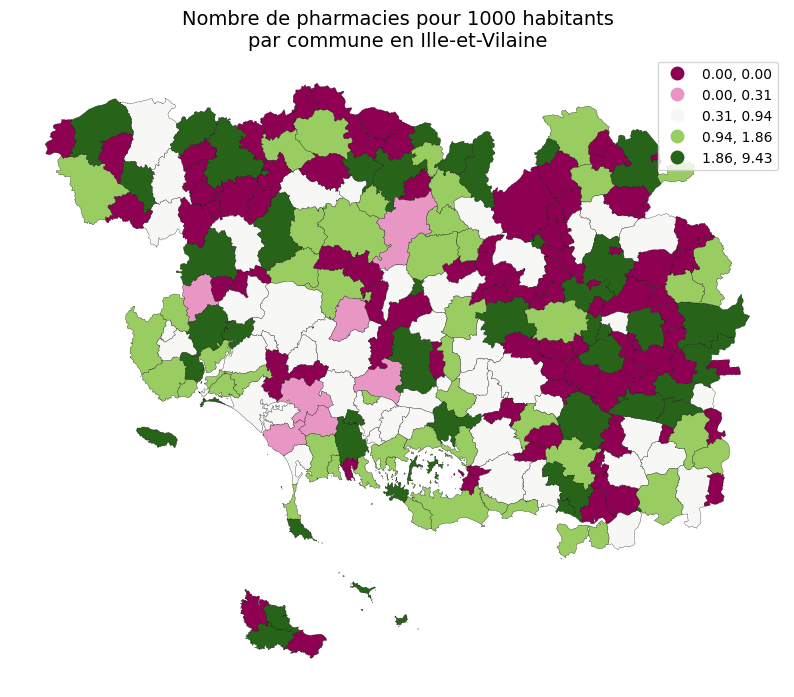

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

Communes35POP.plot(
    column="pharma_pour_1000",
    cmap="PiYG",
    legend=True,
    ax=ax,
    edgecolor="black",
    linewidth=0.2,
    scheme="quantiles"
)

ax.set_title("Nombre de pharmacies pour 1000 habitants\npar commune en Ille-et-Vilaine", fontsize=14)
ax.axis("off")
plt.show()

##🏙️ 🏘️Combien de pharmacie selon le type de commune ? (urbain vs rural)

In [ ]:
Communes35POP["com_uu2020_status"].value_counts()

,count
com_uu2020_status,
hors unité urbaine,172
unité urbaine,77


In [ ]:
# ── 2. Statistiques agrégées par statut UU ─────────────────────────────────
stats_uu = (
    Communes35POP
    .groupby("com_uu2020_status")
    .agg(
        nb_communes        = ("insee_code",      "count"),
        nb_pharmacies_total= ("nb_pharmacies",   "sum"),
        population_totale  = ("Population",      "sum"),
    )
    .reset_index()
)

# Ratio pharmacies / 1000 hab par type de commune
stats_uu["pharma_pour_1000"] = (
    stats_uu["nb_pharmacies_total"] / stats_uu["population_totale"]
) * 1000

# Pharmacies moyennes par commune
stats_uu["pharma_moy_par_commune"] = (
    stats_uu["nb_pharmacies_total"] / stats_uu["nb_communes"]
)

print(stats_uu)

    com_uu2020_status  nb_communes  nb_pharmacies_total  population_totale  \
0  hors unité urbaine          172                235.0             252725   
1       unité urbaine           77                949.0             551872   

   pharma_pour_1000  pharma_moy_par_commune  
0          0.929864                1.366279  
1          1.719602               12.324675  


/tmp/ipykernel_5283/969518146.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(stats_uu["com_uu2020_status"], wrap=True, fontsize=8)
/tmp/ipykernel_5283/969518146.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(stats_uu["com_uu2020_status"], wrap=True, fontsize=8)


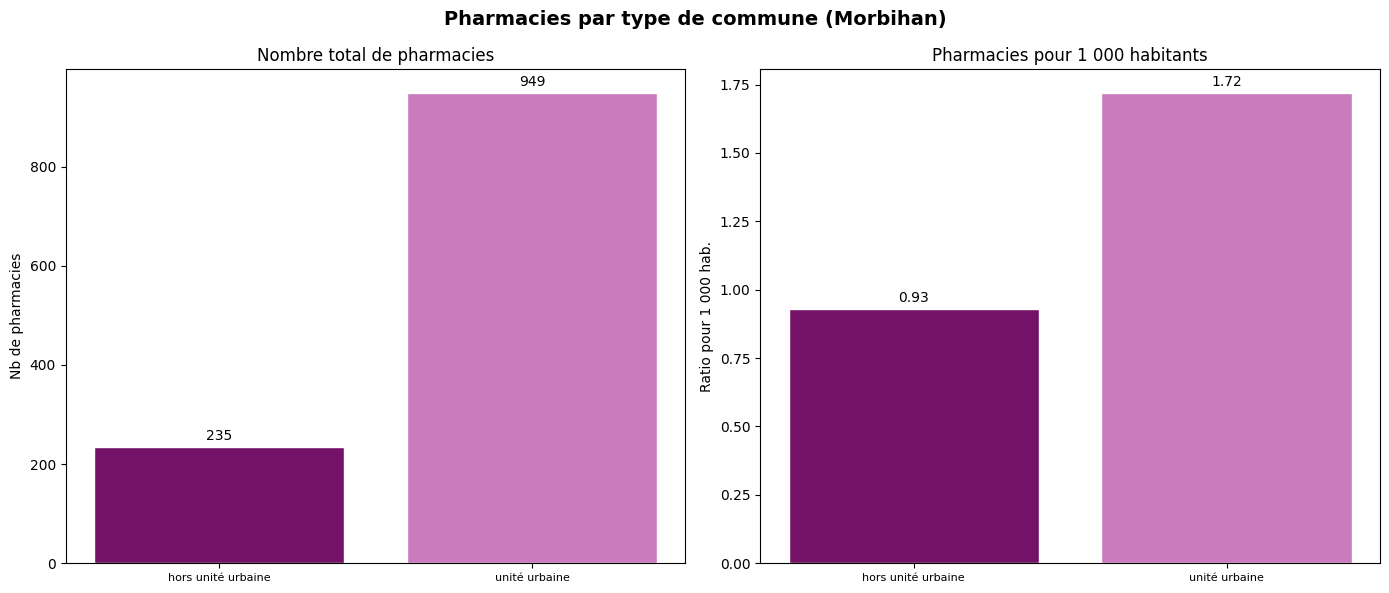

In [ ]:
# ── 3. Visualisation ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Pharmacies par type de commune (Morbihan)", fontsize=14, fontweight="bold")

couleurs = ["#731266", "#C97BBD"]

# --- Graphique 1 : nb total de pharmacies par type ---
axes[0].bar(
    stats_uu["com_uu2020_status"],
    stats_uu["nb_pharmacies_total"],
    color=couleurs,
    edgecolor="white"
)
axes[0].set_title("Nombre total de pharmacies")
axes[0].set_ylabel("Nb de pharmacies")
axes[0].set_xticklabels(stats_uu["com_uu2020_status"], wrap=True, fontsize=8)
axes[0].bar_label(axes[0].containers[0], fmt="%.0f", padding=3)

# --- Graphique 2 : ratio pour 1000 hab ---
axes[1].bar(
    stats_uu["com_uu2020_status"],
    stats_uu["pharma_pour_1000"],
    color=couleurs,
    edgecolor="white"
)
axes[1].set_title("Pharmacies pour 1 000 habitants")
axes[1].set_ylabel("Ratio pour 1 000 hab.")
axes[1].set_xticklabels(stats_uu["com_uu2020_status"], wrap=True, fontsize=8)
axes[1].bar_label(axes[1].containers[0], fmt="%.2f", padding=3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_5283/3651709245.py:17: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centro.geometry = centro["geometry"].centroid


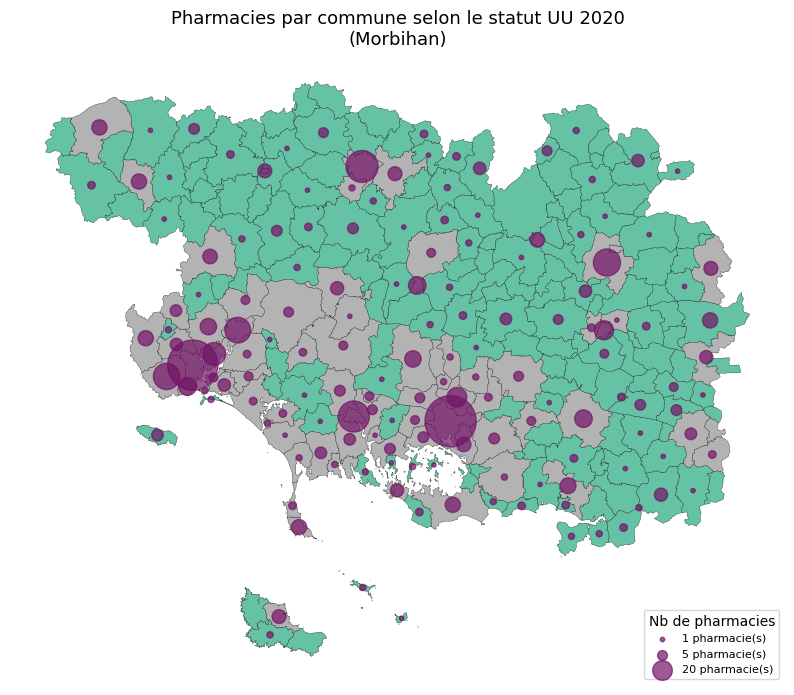

In [ ]:
# ── 4. Carte : statut UU en fond + cercles proportionnels ──────────────────
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Fond choroplèthe selon le statut UU
Communes35POP.plot(
    ax=ax,
    column="com_uu2020_status",
    cmap="Set2",
    edgecolor="black",
    linewidth=0.2,
    legend=True,
    legend_kwds={"loc": "lower left", "fontsize": 7, "title": "Statut UU 2020"}
)

# Cercles proportionnels au nb de pharmacies (communes avec au moins 1)
centro = Communes35POP[Communes35POP["nb_pharmacies"] > 0].copy()
centro.geometry = centro["geometry"].centroid

centro.plot(
    ax=ax,
    markersize=centro["nb_pharmacies"] * 10,
    color="#731266",
    alpha=0.7,
    zorder=3
)

# Légende manuelle cercles
for v in [1, 5, 20]:
    ax.scatter([], [], s=v * 10, color="#731266", alpha=0.7, label=f"{v} pharmacie(s)")

ax.legend(title="Nb de pharmacies", loc="lower right", fontsize=8)
ax.set_title("Pharmacies par commune selon le statut UU 2020\n(Morbihan)", fontsize=13)
ax.axis("off")
plt.show()